### Facility Flood Exposure

**Question:** which health facilities in South Sudan sit in places that flood, how often, and where are they concentrated?

**Approach**
1. Load the 1,747 facilities and the county boundaries with the course loaders, and clean the locations.
2. For every facility, list the flood-mask pixels (≈232 m) whose centre is within 1 km.
3. Scan the flood archive 2003–2025 one year at a time and record every day any of those pixels was flagged as flooded.
4. Summarise per facility, per facility type, per county, per year, and per month.

**Read before interpreting**
* The flood mask is optical. A missing detection means *dry or not visible* (clouds). All exposure numbers are **lower bounds**.
* A flooded pixel within 1 km ≠ the facility was flooded or closed. It is a proxy for disrupted access.
* `recurring` and `unusual` are pooled: `flood_type` is a static per-(pixel, month) lookup, not a property of the event.

In [1]:
import os, sys
from pathlib import Path

# The course loaders use relative paths ('./raw_data/...') and loading_impact_data.py reads the
# admin boundaries AT IMPORT TIME, so the working directory must be the repo root before importing.
REPO = Path.cwd().resolve()
while not (REPO / "processing_data").is_dir():
    if REPO == REPO.parent:
        raise FileNotFoundError("Repo root (folder containing processing_data/) not found")
    REPO = REPO.parent
os.chdir(REPO)
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from processing_data.loading import load_flood_masks
from processing_data.loading_impact_data import (
    load_health_facilities, load_admin_boundaries, locate_coordinate,
)

OUT = REPO / "EDA" / "outputs"
FIG = OUT / "infrastructure_NC_figures"
FIG.mkdir(parents=True, exist_ok=True)

YEARS = range(2003, 2026)     # 2000-2002 excluded: Terra-only period, detections heavily undercounted
N_YEARS = len(YEARS)
RES = 10 / 4800               # flood-mask pixel size in degrees (4800 px per 10-degree tile)
KM_PER_DEG = 111.32
MAX_KM = 1.0                  # neighbourhood radius tracked around each facility
TILE_LAT_MAX = 10.0           # flood tiles h20v08 / h21v08 stop at 10N
RECURRENT_YEARS = int(np.ceil(N_YEARS / 3))   # 8 of 23: the same 1-in-3-years rule NASA uses for 'recurring'

# chart styling (reference palette: light surface, recessive grid, ink for text)
INK, INK2, MUTED, GRID, AXIS, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK2, "axes.titlecolor": INK, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "axes.grid": True, "axes.axisbelow": True, "grid.color": GRID,
    "grid.linewidth": 0.6, "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 12, "axes.titleweight": "bold", "legend.frameon": False,
    "font.family": "sans-serif", "font.sans-serif": ["Segoe UI", "DejaVu Sans"],
})
print("repo root:", REPO)

repo root: C:\Users\nikol\Documents\Capstone_CBL\JBG060_ZHL_2026_Group19


#### 1. Load the facilities
`load_health_facilities()` reads the Sub-Saharan Africa file (69,752 facilities) and keeps South Sudan. It keeps the original index (starting at ~54,786), so reset it.

In [2]:
hf = load_health_facilities().reset_index(drop=True)
print(f"{len(hf)} facilities | CRS: {hf.crs} | FID unique: {hf['FID'].is_unique}")
display(hf.head())
display(pd.concat([hf["Facility_t"].value_counts(), hf["Ownership"].value_counts()], axis=1, keys=["type", "ownership"]).fillna(""))

1747 facilities | CRS: EPSG:4326 | FID unique: True


,FID,Country,Admin1,Facility_n,Facility_t,Ownership,Lat,Long,LL_source,geometry
0,54787,South Sudan,Central Equatoria,Abegi Primary Health Care Unit,Primary Health Care Unit,MoH,4.0131,30.5646,GPS,POINT (30.5646 4.0131)
1,54788,South Sudan,Central Equatoria,Aboroto Primary Health Care Unit,Primary Health Care Unit,MoH,3.6604,30.7097,Geonames,POINT (30.7097 3.6604)
2,54789,South Sudan,Central Equatoria,Adra Primary Health Care Unit,Primary Health Care Unit,MoH,5.4340,31.7504,GPS,POINT (31.7504 5.434)
3,54790,South Sudan,Central Equatoria,Agonyakiri Primary Health Care Unit,Primary Health Care Unit,MoH,3.9285,30.5144,GPS,POINT (30.5144 3.9285)
4,54791,South Sudan,Central Equatoria,Aic Buluk Primary Health Care Unit,Primary Health Care Unit,MoH,4.8480,31.5931,GPS,POINT (31.5931 4.848)


,type,ownership
Primary Health Care Unit,1375.0,
Primary Health Care Centre,332.0,
County Hospital,28.0,
State Hospital,9.0,
Teaching Hospital,3.0,
MoH,,1732.0
FBO/NGO,,15.0


#### 2. Location quality checks
The loader does no cleaning. Three problems:
* **Null Island:** 13 facilities have `Lat = Long = 0` and an empty geometry. Left in, they land in the Atlantic, never flood, and quietly count as "not exposed".
* **Location source:** `Geonames` means the location was matched from a place name, not measured. That can be kilometres off, which matters for a 1 km buffer.
* **Shared coordinates:** some facilities share an exact location (e.g. several clinics in one IDP camp). That's real, but it inflates per-county counts.

In [3]:
no_loc = ((hf["Lat"] == 0) & (hf["Long"] == 0)) | hf.geometry.is_empty | hf.geometry.isna()
print(f"no usable location: {no_loc.sum()}")
display(hf.loc[no_loc, ["FID", "Facility_n", "Facility_t", "Admin1"]])
hf = hf.loc[~no_loc].reset_index(drop=True)

display(hf["LL_source"].replace("", "(blank)").value_counts().to_frame("facilities"))

dup = hf.duplicated(["Lat", "Long"], keep=False)
print(f"facilities sharing exact coordinates with another facility: {dup.sum()}")
display(hf.loc[dup, ["Facility_n", "Facility_t", "Admin1", "Lat", "Long"]].sort_values(["Lat", "Long"]).head(10))

no usable location: 13


,FID,Facility_n,Facility_t,Admin1
83,54870,Jurtong Primary Health Care Centre,Primary Health Care Centre,Central Equatoria
230,55017,Mogiri Lainya Primary Health Care Unit,Primary Health Care Unit,Central Equatoria
381,55168,Emedu Primary Health Care Unit,Primary Health Care Unit,Eastern Equatoria
529,55316,Nakware Primary Health Care Unit,Primary Health Care Unit,Eastern Equatoria
560,55347,Offiriha Primary Health Care Unit,Primary Health Care Unit,Eastern Equatoria
561,55348,Offiriha Primary Health Care Unit,Primary Health Care Unit,Eastern Equatoria
579,55366,Orphan Primary Health Care Unit,Primary Health Care Unit,Eastern Equatoria
1297,56084,Aloor Primary Health Care Unit,Primary Health Care Unit,Warrap
1318,56105,Indeed Truth Primary Health Care Unit,Primary Health Care Unit,Warrap
1389,56176,Rumabuth Primary Health Care Unit,Primary Health Care Unit,Warrap


,facilities
LL_source,
GPS,1382
Geonames,349
Google Earth,3


facilities sharing exact coordinates with another facility: 62


,Facility_n,Facility_t,Admin1,Lat,Long
514,Mugali Primary Health Care Unit,Primary Health Care Unit,Eastern Equatoria,3.5667,32.1976
519,Mutebwa Primary Health Care Unit,Primary Health Care Unit,Eastern Equatoria,3.5667,32.1976
550,Nyaciga Jun. Offi. Military Academy (Njoma) Pr...,Primary Health Care Centre,Eastern Equatoria,3.8404,32.2517
555,Offi Longelwa Primary Health Care Unit,Primary Health Care Unit,Eastern Equatoria,3.8404,32.2517
575,Owinykibul Primary Health Care Unit,Primary Health Care Unit,Eastern Equatoria,3.8411,32.2657
576,Owinykibul Primary Health Care Unit,Primary Health Care Unit,Eastern Equatoria,3.8411,32.2657
476,lomwoo Primary Health Care Unit,Primary Health Care Unit,Eastern Equatoria,4.0844,32.9354
477,Lomwoo Primary Health Care Unit,Primary Health Care Unit,Eastern Equatoria,4.0844,32.9354
498,Magwi CDOT Primary Health Care Unit,Primary Health Care Unit,Eastern Equatoria,4.1229,32.3043
499,Magwi Dot Primary Health Care Centre,Primary Health Care Centre,Eastern Equatoria,4.1229,32.3043


#### 3. Attach counties (admin-2)
A spatial join (`gpd.sjoin`) handles all facilities in one call. The course's `locate_coordinate()` is fine for a single point, but it scans every polygon per call, prints a warning for every miss, and returns the *string* `"None"` instead of `None`. We only use it to spot-check the join.

A few facilities fall just outside the national border (GPS/boundary precision). They're snapped to the nearest county if it's ≤ 2 km away; anything further is treated as a coordinate error and excluded.

In [4]:
adm1, adm2 = load_admin_boundaries()
ADM_COLS = ["adm2_name", "adm2_pcode", "adm1_name", "geometry"]
hf = hf.drop(columns=[c for c in ADM_COLS[:-1] + ["index_right"] if c in hf], errors="ignore")
hf = gpd.sjoin(hf, adm2[ADM_COLS], how="left", predicate="within").drop(columns="index_right")
assert hf.index.is_unique, "a facility matched two counties"

miss = hf["adm2_name"].isna()
utm = 32636   # UTM zone 36N, a metric CRS so distances come out in metres
near = gpd.sjoin_nearest(hf.loc[miss, ["Facility_n", "geometry"]].to_crs(utm), adm2[ADM_COLS].to_crs(utm),
                         distance_col="dist_to_county_m")
display(near.drop(columns=["geometry", "index_right"]).round(0))
snap = near.index[near["dist_to_county_m"] <= 2000]
hf.loc[snap, ["adm2_name", "adm2_pcode", "adm1_name"]] = near.loc[snap, ["adm2_name", "adm2_pcode", "adm1_name"]].to_numpy()

hf["location_flag"] = ""
hf.loc[hf["adm2_name"].isna(), "location_flag"] = "outside South Sudan"
wrong_state = hf["adm1_name"].notna() & (hf["Admin1"] != hf["adm1_name"])
hf.loc[wrong_state, "location_flag"] = "Admin1 label != state it falls in"
print(f"facilities whose own Admin1 label disagrees with their location: {wrong_state.sum()}")
display(hf.loc[wrong_state, ["Facility_n", "Admin1", "adm1_name", "adm2_name", "LL_source"]])

# spot-check against the course function
for _, r in hf.sample(5, random_state=1).iterrows():
    print(f"{r['Facility_n'][:42]:<42} sjoin: {str(r['adm2_name']):<16} locate_coordinate: {locate_coordinate(r['Long'], r['Lat'])[1]}")

,Facility_n,adm2_name,adm2_pcode,adm1_name,dist_to_county_m
12,Bamurey Primary Health Care Centre,Kajo-keji,SS0102,Central Equatoria,175.0
299,Sare Jale Primary Health Care Unit,Kajo-keji,SS0102,Central Equatoria,999.0
992,Rupaker Primary Health Care Unit,Aweil East,SS0502,Northern Bahr el Ghazal,26580.0


facilities whose own Admin1 label disagrees with their location: 4


,Facility_n,Admin1,adm1_name,adm2_name,LL_source
115,Kit One Primary Health Care Unit,Central Equatoria,Eastern Equatoria,Magwi,Geonames
820,Jarweng Primary Health Care Unit,Lakes,Jonglei,Bor South,GPS
1292,Angui Primary Health Care Unit,Warrap,Northern Bahr el Ghazal,Aweil East,GPS
1294,Angur Primary Health Care Unit,Warrap,Western Bahr el Ghazal,Jur River,GPS


Kiju Primary Health Care Unit              sjoin: Lainya           locate_coordinate: Lainya
Kk Romogi Primary Health Care Unit         sjoin: Kajo-keji        locate_coordinate: Kajo-keji
Bakon Primary Health Care Unit             sjoin: Aweil East       locate_coordinate: Aweil East
Palok Primary Health Care Unit             sjoin: Rumbek East      locate_coordinate: Rumbek East
Duar Primary Health Care Unit              sjoin: Guit             locate_coordinate: Guit


#### 4. Flood-mask coverage
The two flood tiles stop at 10°N, but South Sudan runs to 12.2°N. Facilities north of that have **no data**, which is not the same as *no flooding*. They're kept visible but excluded from the exposure statistics.

In [5]:
hf["has_flood_data"] = hf["Lat"] < TILE_LAT_MAX
hf["analysable"] = hf["has_flood_data"] & hf["adm2_name"].notna()
print(f"north of 10N (no flood data): {(~hf['has_flood_data']).sum()}  |  analysable: {hf['analysable'].sum()} of {len(hf)}")
display(hf.loc[~hf["has_flood_data"]].groupby(["adm1_name", "adm2_name"]).size().to_frame("facilities without flood data"))

north of 10N (no flood data): 49  |  analysable: 1684 of 1734


facilities without flood data
adm1_name  adm2_name                               
Unity      Pariang                                1
Upper Nile Fashoda                                3
           Maban                                  4
           Manyo                                 13
           Melut                                  9
           Renk                                  19

#### 5. Which pixels surround each facility?
The flood mask is a fixed grid with pixel **centres** at `(k + 0.5) × RES` degrees. Snap coordinates with `floor(coord / RES)`: `round()` would be a coin flip exactly at .5, so neighbouring pixels could collide.

For every facility, list every pixel whose centre lies within 1 km. That's ~58 pixels each, plus the facility's own pixel. The distance is kept, so smaller radii can be analysed from the same table.

In [6]:
def cell(deg):
    # index of the flood-mask pixel containing a coordinate
    return np.floor(np.asarray(deg, dtype=np.float64) / RES).astype(np.int64)

def pixel_id(row, col):
    return row * 1_000_000 + col

K = int(np.ceil(MAX_KM / (KM_PER_DEG * RES))) + 1                  # search box half-width, in pixels
d_r, d_c = [a.ravel() for a in np.meshgrid(np.arange(-K, K + 1), np.arange(-K, K + 1), indexing="ij")]

f = hf.loc[hf["analysable"], ["FID", "Lat", "Long"]]
r0, c0 = cell(f["Lat"]), cell(f["Long"])
rows, cols = (r0[:, None] + d_r).ravel(), (c0[:, None] + d_c).ravel()
lat_f, lon_f = np.repeat(f["Lat"].to_numpy(), d_r.size), np.repeat(f["Long"].to_numpy(), d_r.size)

nb = pd.DataFrame({
    "fid": np.repeat(f["FID"].to_numpy(), d_r.size),
    "pid": pixel_id(rows, cols),
    "dist_km": np.hypot(((rows + 0.5) * RES - lat_f) * KM_PER_DEG,
                        ((cols + 0.5) * RES - lon_f) * KM_PER_DEG * np.cos(np.radians(lat_f))),
    "own_pixel": (rows == np.repeat(r0, d_r.size)) & (cols == np.repeat(c0, d_r.size)),
})
nb = nb[nb["dist_km"] <= MAX_KM].reset_index(drop=True)
print(f"{nb['fid'].nunique()} facilities | {len(nb):,} facility-pixel pairs | "
      f"{nb.groupby('fid').size().mean():.0f} pixels per facility")

1684 facilities | 99,048 facility-pixel pairs | 59 pixels per facility


#### 6. Scan the flood archive (runs once, then cached)
`load_flood_masks()` cannot be called for all years at once: 95 M rows would exhaust memory. So it's called one year at a time (2023, the largest, takes ~17 s), and each year is immediately reduced to the pixels around facilities.

Result: one row per *(flooded pixel, day, facility within 1 km)*. It's cached to `EDA/outputs/`. Delete the cache file to recompute (it's recomputed automatically if the facility set changes).

In [7]:
CACHE = OUT / f"facility_flood_hits_{MAX_KM:g}km.parquet"
CACHE_KEY = OUT / f"facility_flood_hits_{MAX_KM:g}km_neighbourhoods.parquet"

if CACHE.exists() and CACHE_KEY.exists() and pd.read_parquet(CACHE_KEY).equals(nb):
    hits = pd.read_parquet(CACHE)
    print(f"loaded cache: {len(hits):,} rows")
else:
    tracked = np.unique(nb["pid"].to_numpy())
    parts = []
    for y in YEARS:
        fm = load_flood_masks(np.array([y]))                          # course loader, one year at a time
        fm["pid"] = pixel_id(cell(fm["lat"]), cell(fm["lon"]))
        fm = fm.loc[np.isin(fm["pid"].to_numpy(), tracked), ["date", "pid", "flood_type"]]
        parts.append(fm.merge(nb, on="pid", how="inner"))
        print(f"{y}: {len(parts[-1]):>9,} hits")
        del fm
    hits = pd.concat(parts, ignore_index=True)
    hits.to_parquet(CACHE, index=False)
    nb.to_parquet(CACHE_KEY, index=False)
display(hits.head())

loaded cache: 399,040 rows


,date,pid,flood_type,fid,dist_km,own_pixel
0,2003-01-01,2359015196,1,54836,0.929941,False
1,2003-01-01,2359015196,1,54837,0.733525,False
2,2003-01-01,2712015226,1,55036,0.805541,False
3,2003-01-01,2902015129,1,55612,0.615941,False
4,2003-01-01,2902015129,1,55649,0.615941,False


#### 7. Exposure metrics per facility
For each facility, and for three radii (own pixel ≈ 230 m, 0.5 km, 1 km):

| metric | meaning |
|---|---|
| `flood_years` | years (of 23) with ≥ 1 flooded pixel within the radius. **Main metric.** |
| `flood_days` | days with ≥ 1 flooded pixel. Overstates *events*: each day is a 3-day composite, so consecutive days overlap |
| `max_frac_flooded` | on the worst day, the share of the neighbourhood under water (0–1) |
| `days_half_flooded` | days with ≥ 50 % of the neighbourhood flooded, i.e. the facility is largely surrounded |

**Exposure class** (1 km): `never` · `occasional` (1–7 years) · `recurrent` (≥ 8 of 23 years, NASA's one-in-three rule) · `no data`.

In [8]:
def daily_table(h, n):
    # one row per (facility, day): number and share of neighbourhood pixels flooded
    n_pix = n.groupby("fid").size()
    d = h.groupby(["fid", "date"])["pid"].nunique().rename("px").reset_index()
    d["frac"] = d["px"] / d["fid"].map(n_pix)
    d["year"] = d["date"].dt.year
    return d, n_pix

def summarise(d, n_pix):
    g = d.assign(half=d["frac"] >= 0.5).groupby("fid")
    out = pd.DataFrame({
        "flood_years": g["year"].nunique(),
        "flood_days": g.size(),
        "max_frac_flooded": g["frac"].max().round(3),
        "days_half_flooded": g["half"].sum(),
    })
    return out.reindex(n_pix.index, fill_value=0)       # facilities never flooded -> 0

SEL = {
    "own pixel": lambda t: t["own_pixel"],
    "0.5 km":    lambda t: t["dist_km"] <= 0.5,
    "1 km":      lambda t: t["dist_km"] <= MAX_KM,
}
daily, exp = {}, {}
for name, sel in SEL.items():
    daily[name], n_pix = daily_table(hits[sel(hits)], nb[sel(nb)])
    exp[name] = summarise(daily[name], n_pix)

METRICS = ["flood_years", "flood_days", "max_frac_flooded", "days_half_flooded",
           "own_pixel_flood_years", "flood_years_0.5km", "exposure"]
hf = hf.drop(columns=[c for c in METRICS if c in hf])
hf = hf.merge(exp["1 km"], left_on="FID", right_index=True, how="left")
hf["own_pixel_flood_years"] = hf["FID"].map(exp["own pixel"]["flood_years"])
hf["flood_years_0.5km"] = hf["FID"].map(exp["0.5 km"]["flood_years"])
hf["exposure"] = np.select(
    [~hf["analysable"], hf["flood_years"] == 0, hf["flood_years"] < RECURRENT_YEARS],
    ["no data", "never", "occasional"], "recurrent")
ORDER = ["never", "occasional", "recurrent", "no data"]
display(hf["exposure"].value_counts().reindex(ORDER).to_frame("facilities"))

,facilities
exposure,
never,1176
occasional,441
recurrent,67
no data,50


**Sensitivity to the radius.** If the conclusions only hold at one radius, they're fragile. Also compare GPS-located facilities with Geonames-located ones: a large gap would suggest location error is driving results.

In [9]:
def row(e):
    ever, rec = e["flood_years"] > 0, e["flood_years"] >= RECURRENT_YEARS
    return {"facilities": len(e), "ever flooded": int(ever.sum()), "ever %": round(100 * ever.mean(), 1),
            f"recurrent (>= {RECURRENT_YEARS}/{N_YEARS} yrs)": int(rec.sum()), "recurrent %": round(100 * rec.mean(), 1)}
display(pd.DataFrame({k: row(e) for k, e in exp.items()}).T)

a = hf[hf["analysable"]]
display(pd.crosstab(a["LL_source"].replace("", "(blank)"), a["exposure"], normalize="index")
          .mul(100).round(1).reindex(columns=ORDER[:3]).assign(n=a["LL_source"].replace("", "(blank)").value_counts()))

,facilities,ever flooded,ever %,recurrent (>= 8/23 yrs),recurrent %
own pixel,1684.0,68.0,4.0,0.0,0.0
0.5 km,1684.0,283.0,16.8,16.0,1.0
1 km,1684.0,508.0,30.2,67.0,4.0


exposure,never,occasional,recurrent,n
LL_source,,,,
GPS,69.8,26.5,3.7,1337
Geonames,70.1,25.0,4.9,344
Google Earth,66.7,33.3,0.0,3


#### 8. Which facilities, and which types?

In [10]:
cols = ["Facility_n", "Facility_t", "adm1_name", "adm2_name", "flood_years", "days_half_flooded",
        "max_frac_flooded", "own_pixel_flood_years", "LL_source"]
display(a.sort_values(["flood_years", "days_half_flooded", "flood_days"], ascending=False)[cols].head(20))

by_type = pd.crosstab(a["Facility_t"], a["exposure"]).reindex(columns=ORDER[:3], fill_value=0)
by_type["total"] = by_type.sum(axis=1)
by_type["recurrent %"] = (100 * by_type["recurrent"] / by_type["total"]).round(1)
display(by_type.sort_values("recurrent %", ascending=False))

,Facility_n,Facility_t,adm1_name,adm2_name,flood_years,days_half_flooded,max_frac_flooded,own_pixel_flood_years,LL_source
818,IMC Site 2 _Awerial Primary Health Care Unit,Primary Health Care Unit,Lakes,Awerial,23.0,0.0,0.138,0.0,Geonames
855,Mingkaman Primary Health Care Unit,Primary Health Care Unit,Lakes,Awerial,23.0,0.0,0.138,0.0,Geonames
874,SMC _Awerial Primary Health Care Centre,Primary Health Care Centre,Lakes,Awerial,23.0,0.0,0.133,0.0,Geonames
50,Gondokoro Primary Health Care Unit,Primary Health Care Unit,Central Equatoria,Juba,23.0,0.0,0.155,0.0,GPS
49,Gondokoro Main Land Primary Health Care Unit,Primary Health Care Unit,Central Equatoria,Juba,23.0,0.0,0.107,0.0,GPS
1149,Bieng Thiang Primary Health Care Unit,Primary Health Care Unit,Upper Nile,Baliet,23.0,0.0,0.193,0.0,GPS
207,Mahad Primary Sch. Primary Health Care Centre,Primary Health Care Centre,Central Equatoria,Juba,23.0,0.0,0.103,0.0,Geonames
873,Shambe Primary Health Care Centre,Primary Health Care Centre,Lakes,Yirol East,22.0,0.0,0.167,2.0,GPS
71,Jandoru Primary Health Care Unit,Primary Health Care Unit,Central Equatoria,Juba,22.0,0.0,0.050,0.0,GPS
643,Dilule Primary Health Care Unit,Primary Health Care Unit,Jonglei,Akobo,21.0,0.0,0.172,0.0,GPS


exposure,never,occasional,recurrent,total,recurrent %
Facility_t,,,,,
Teaching Hospital,1,1,1,3,33.3
Primary Health Care Centre,216,89,16,321,5.0
County Hospital,19,6,1,26,3.8
Primary Health Care Unit,934,342,49,1325,3.7
State Hospital,6,3,0,9,0.0


#### 9. By county
Percentages in counties with few facilities are unstable. Always read them next to `facilities`.

,adm1_name,adm2_name,adm2_pcode,facilities,no_flood_data,ever_flooded,recurrent,median_flood_years,pct_ever,pct_recurrent
0,Upper Nile,Ulang,SS0712,8,0,8,5,10.0,100.0,62.5
1,Upper Nile,Panyikang,SS0710,9,0,9,4,5.0,100.0,44.4
2,Jonglei,Canal/Pigi,SS0304,8,0,6,3,5.0,75.0,37.5
3,Upper Nile,Fashoda,SS0702,12,3,9,3,3.0,100.0,33.3
4,Lakes,Awerial,SS0401,14,0,4,4,0.0,28.6,28.6
5,Warrap,Twic,SS0806,25,0,14,5,2.0,56.0,20.0
6,Unity,Guit,SS0602,11,0,10,2,5.0,90.9,18.2
7,Upper Nile,Luakpiny/Nasir,SS0704,17,0,13,3,2.0,76.5,17.6
8,Jonglei,Akobo,SS0301,14,0,10,2,2.0,71.4,14.3
9,Jonglei,Twic East,SS0310,14,0,14,2,5.0,100.0,14.3


counties with >= 1 recurrently exposed facility: 31 of 78


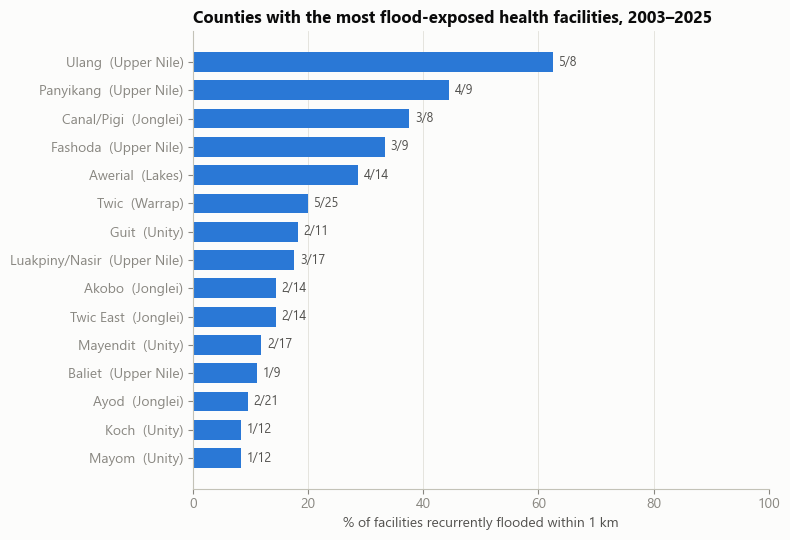

In [11]:
g = hf[hf["adm2_name"].notna()].groupby(["adm1_name", "adm2_name", "adm2_pcode"])
county = pd.DataFrame({
    "facilities": g.size(),
    "no_flood_data": g["has_flood_data"].apply(lambda s: int((~s).sum())),
    "ever_flooded": g["flood_years"].apply(lambda s: int((s > 0).sum())),
    "recurrent": g["exposure"].apply(lambda s: int((s == "recurrent").sum())),
    "median_flood_years": g["flood_years"].median(),
}).reset_index()
with_data = (county["facilities"] - county["no_flood_data"]).replace(0, np.nan)
county["pct_ever"] = (100 * county["ever_flooded"] / with_data).round(1)
county["pct_recurrent"] = (100 * county["recurrent"] / with_data).round(1)
county = county.sort_values(["pct_recurrent", "recurrent"], ascending=False).reset_index(drop=True)
display(county.head(20))
print(f"counties with >= 1 recurrently exposed facility: {(county['recurrent'] > 0).sum()} of {len(county)}")

top = county[county["recurrent"] > 0].head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(top["adm2_name"] + "  (" + top["adm1_name"] + ")", top["pct_recurrent"], height=0.7, color="#2a78d6")
for y_, (p, r_, n_) in enumerate(zip(top["pct_recurrent"], top["recurrent"], top["facilities"] - top["no_flood_data"])):
    ax.text(p + 1, y_, f"{r_}/{n_}", va="center", fontsize=9, color=INK2)
ax.set_xlabel("% of facilities recurrently flooded within 1 km")
ax.set_xlim(0, 100); ax.grid(axis="y", visible=False)
ax.set_title(f"Counties with the most flood-exposed health facilities, {YEARS[0]}–{YEARS[-1]}", loc="left")
plt.tight_layout(); fig.savefig(FIG / "facility_exposure_by_county.png", dpi=200); plt.show()

#### 10. Map

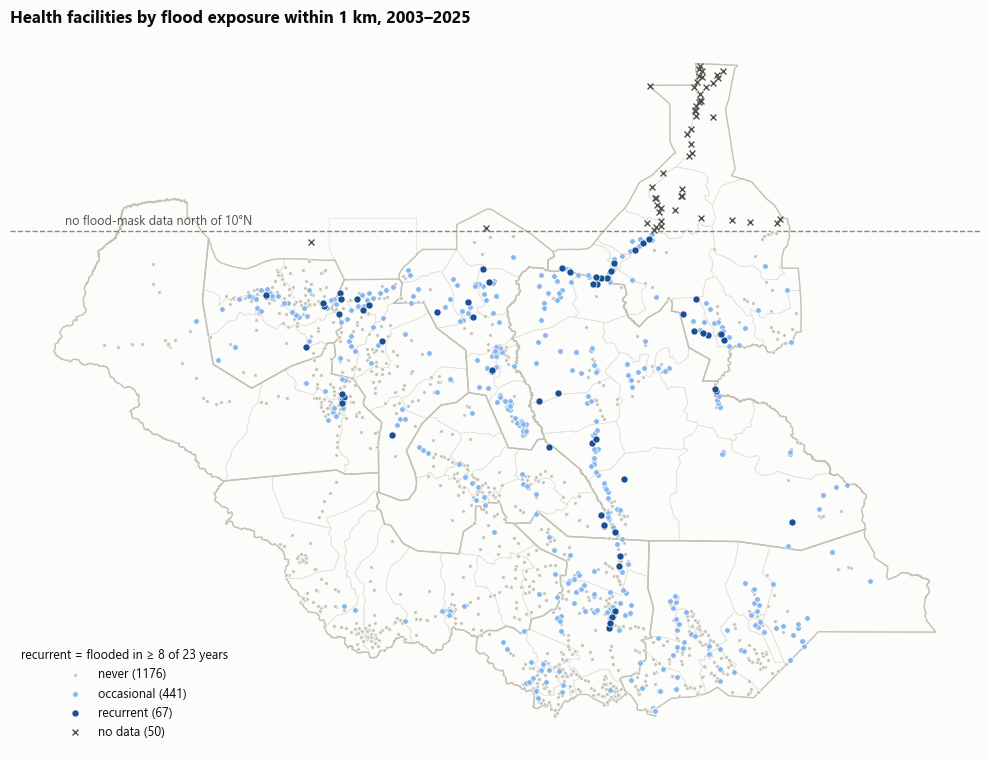

In [12]:
STYLE = {   # (colour, size, marker): ordinal blue for exposure, neutral for none, colourless cross for no data
    "never":      ("#c3c2b7", 7,  "o"),
    "occasional": ("#86b6ef", 16, "o"),
    "recurrent":  ("#184f95", 26, "o"),
    "no data":    (INK2,      18, "x"),
}
fig, ax = plt.subplots(figsize=(10, 9))
adm2.boundary.plot(ax=ax, color=GRID, linewidth=0.5)
adm1.boundary.plot(ax=ax, color=AXIS, linewidth=1.0)
for cat, (col, size, mk) in STYLE.items():
    s = hf[hf["exposure"] == cat]
    kw = dict(edgecolors=SURFACE, linewidths=0.5) if mk == "o" else dict(linewidths=1.0)
    ax.scatter(s["Long"], s["Lat"], s=size, c=col, marker=mk, label=f"{cat} ({len(s)})", zorder=3, **kw)
ax.axhline(TILE_LAT_MAX, color=MUTED, ls="--", lw=1)
ax.text(24.3, TILE_LAT_MAX + 0.08, "no flood-mask data north of 10°N", color=INK2, fontsize=9)
ax.set_title(f"Health facilities by flood exposure within 1 km, {YEARS[0]}–{YEARS[-1]}", loc="left")
ax.legend(loc="lower left", title=f"recurrent = flooded in ≥ {RECURRENT_YEARS} of {N_YEARS} years", fontsize=9, title_fontsize=9)
ax.set_aspect("equal"); ax.grid(False)
for s_ in ax.spines.values(): s_.set_visible(False)
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); fig.savefig(FIG / "facility_exposure_map.png", dpi=200); plt.show()

#### 11. Through time
How many facilities had flooding within 1 km each year? Pooled classes, so the recurring/unusual artefact doesn't matter here. Expect a step change around 2020–21, when the equatorial lakes rose ~1.5 m and stayed high.

year,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
any flooding within 1 km,81,46,54,64,103,110,55,72,38,63,...,56,51,48,52,174,202,182,136,145,94
≥ 50% of 1 km flooded,0,0,0,0,0,5,0,0,0,2,...,0,0,0,0,6,13,20,17,13,4


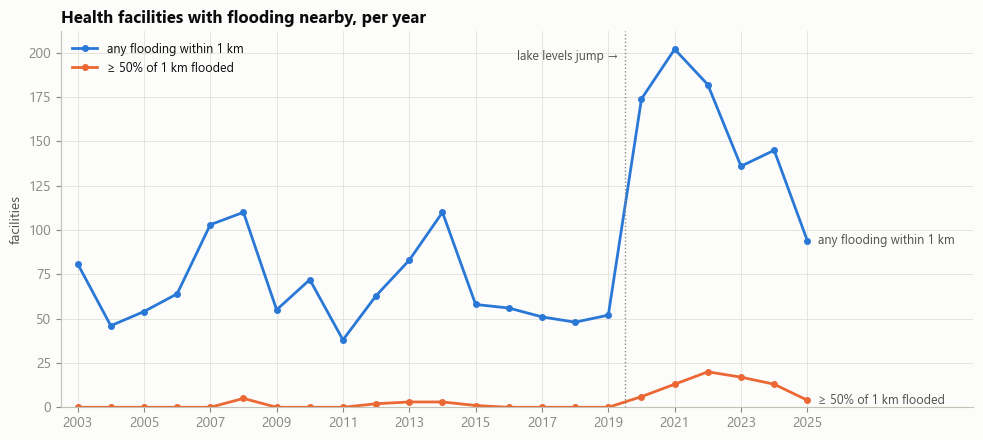

In [13]:
d1 = daily["1 km"]
per_year = pd.DataFrame({
    "any flooding within 1 km": d1.groupby("year")["fid"].nunique(),
    "≥ 50% of 1 km flooded":    d1[d1["frac"] >= 0.5].groupby("year")["fid"].nunique(),
}).reindex(YEARS).fillna(0).astype(int)
display(per_year.T)

fig, ax = plt.subplots(figsize=(10, 4.5))
for (name, s), col in zip(per_year.items(), ["#2a78d6", "#eb6834"]):
    ax.plot(s.index, s.to_numpy(), color=col, lw=2, marker="o", ms=4, label=name)
    ax.annotate(name, (s.index[-1], s.iloc[-1]), xytext=(8, 0), textcoords="offset points",
                va="center", fontsize=9, color=INK2)
ax.axvline(2019.5, color=MUTED, ls=":", lw=1)
ax.text(2019.3, ax.get_ylim()[1] * 0.95, "lake levels jump →", color=INK2, fontsize=9, va="top", ha="right")
ax.set_xlim(YEARS[0] - 0.5, YEARS[-1] + 5); ax.set_xticks(list(YEARS)[::2])
ax.set_ylabel("facilities"); ax.set_ylim(bottom=0)
ax.set_title("Health facilities with flooding nearby, per year", loc="left")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout(); fig.savefig(FIG / "facility_exposure_per_year.png", dpi=200); plt.show()

#### 12. Seasonality: read with caution
This counts *detections*, not flood timing. Detections are lowest in the rainy season (Jul–Aug) because clouds hide the ground, and highest in Dec–Jan when skies are clear and water is still standing. Across the whole tile, monthly detections correlate **−0.63** with rainfall. So this chart shows *when flooding is visible*, not *when facilities get cut off*.

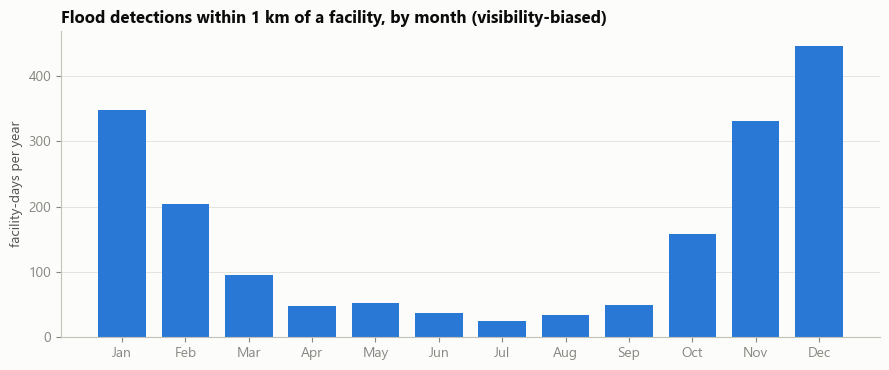

In [14]:
by_month = d1.groupby(d1["date"].dt.month).size().reindex(range(1, 13), fill_value=0) / N_YEARS
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.bar([pd.Timestamp(2000, m, 1).strftime("%b") for m in by_month.index], by_month.to_numpy(), width=0.75, color="#2a78d6")
ax.grid(axis="x", visible=False)
ax.set_ylabel("facility-days per year")
ax.set_title("Flood detections within 1 km of a facility, by month (visibility-biased)", loc="left")
plt.tight_layout(); fig.savefig(FIG / "facility_exposure_by_month.png", dpi=200); plt.show()

#### 13. Save

In [16]:
hf.head()

,FID,Country,Admin1,Facility_n,Facility_t,Ownership,Lat,Long,LL_source,geometry,...,location_flag,has_flood_data,analysable,flood_years,flood_days,max_frac_flooded,days_half_flooded,own_pixel_flood_years,flood_years_0.5km,exposure
0,54787,South Sudan,Central Equatoria,Abegi Primary Health Care Unit,Primary Health Care Unit,MoH,4.0131,30.5646,GPS,POINT (30.5646 4.0131),...,,True,True,1.0,1.0,0.017,0.0,0.0,0.0,occasional
1,54788,South Sudan,Central Equatoria,Aboroto Primary Health Care Unit,Primary Health Care Unit,MoH,3.6604,30.7097,Geonames,POINT (30.7097 3.6604),...,,True,True,0.0,0.0,0.000,0.0,0.0,0.0,never
2,54789,South Sudan,Central Equatoria,Adra Primary Health Care Unit,Primary Health Care Unit,MoH,5.4340,31.7504,GPS,POINT (31.7504 5.434),...,,True,True,1.0,3.0,0.102,0.0,0.0,0.0,occasional
3,54790,South Sudan,Central Equatoria,Agonyakiri Primary Health Care Unit,Primary Health Care Unit,MoH,3.9285,30.5144,GPS,POINT (30.5144 3.9285),...,,True,True,0.0,0.0,0.000,0.0,0.0,0.0,never
4,54791,South Sudan,Central Equatoria,Aic Buluk Primary Health Care Unit,Primary Health Care Unit,MoH,4.8480,31.5931,GPS,POINT (31.5931 4.848),...,,True,True,0.0,0.0,0.000,0.0,0.0,0.0,never


In [15]:
keep = ["FID", "Facility_n", "Facility_t", "Ownership", "Admin1", "adm1_name", "adm2_name", "adm2_pcode",
        "Lat", "Long", "LL_source", "location_flag", "has_flood_data", "analysable"] + METRICS
hf[keep].to_csv(OUT / "facility_flood_exposure.csv", index=False)
county.to_csv(OUT / "county_facility_flood_exposure.csv", index=False)
per_year.to_csv(OUT / "facility_flood_exposure_per_year.csv")
print("saved to", OUT)

saved to C:\Users\nikol\Documents\Capstone_CBL\JBG060_ZHL_2026_Group19\EDA\outputs


#### Limitations to carry into the report
* **Lower bound.** Optical satellite, so cloud-hidden flooding is missed, especially in the rainy season.
* **Proxy.** Water within 1 km ≠ facility closed. It indicates likely disrupted access.
* **Resolution.** 232 m pixels miss narrow flooding (roads, compounds, towns under tree cover or rooftops).
* **Coverage.** Nothing north of 10°N (Renk, Manyo, most of Melut); years 2003–2025 only.
* **Locations.** ~20 % located via place-name lookup (`Geonames`); 13 had no location; the list is a 2019 snapshot, before the 2020–22 floods.
* **`flood_days` ≠ events.** Consecutive days share 3-day composites.